In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def img_details(name,img):
   print(f'{name}',img.shape)
   cv2.imshow(f'{name}{img.shape}',img)
   cv2.waitKey(0)
   cv2.destroyAllWindows()

In [31]:
def col_space_conv(name,img,conv):
    conv_img = cv2.cvtColor(img,conv)
    img_details(name,conv_img)

    return conv_img

In [32]:
def print_resize_img(name,img,scl=0.5):
    # Resize(more than one tecnique)
    lst_interpol = [cv2.INTER_NEAREST,cv2.INTER_LINEAR,cv2.INTER_CUBIC,cv2.INTER_AREA,cv2.INTER_LANCZOS4]
    method_names = ['INTER_NEAREST','INTER_LINEAR','INTER_CUBIC','INTER_AREA','INTER_LANCZOS4']

    resized_img = []
    for i in range(5):
        resized_img.append(cv2.resize(img,dsize=None,fx=scl,fy=scl,interpolation=lst_interpol[i]))

    for i in range(5):
        cv2.imshow(f'{name}({method_names[i]}){resized_img[i].shape}',resized_img[i])

    cv2.waitKey(0)
    cv2.destroyAllWindows()

    return resized_img

# Read The Image 

In [33]:
img1 = cv2.imread(r"D:\COLLEGE\COMPUTER VISION\IMAGES\Lena")
img2 = cv2.imread(r"D:\COLLEGE\COMPUTER VISION\IMAGES\Computer Vision.jpg")

img_details('Lenna(Original)',img1)
img_details('Computer Vision(Original)',img2)

Lenna(Original) (360, 360, 3)
Computer Vision(Original) (900, 1200, 3)


# Resize The Image

In [34]:
re_lenna = print_resize_img('Lenna',img1,scl=1.4)
re_cv = print_resize_img('Computer Vision',img2,scl=0.5)

# Convert to Gray Scale(more than one technique)

# INBUILT FUNCTION

# Using OpenCV

In [7]:
lenna_gray = col_space_conv('Lenna(grayscale)',re_lenna[0],cv2.COLOR_BGR2GRAY)
cv_gray = col_space_conv('Computer Vision(grayscale)',re_cv[0],cv2.COLOR_BGR2GRAY)

Lenna(grayscale) (504, 504)
Computer Vision(grayscale) (450, 600)


# Using Scikit

In [8]:
from skimage import color

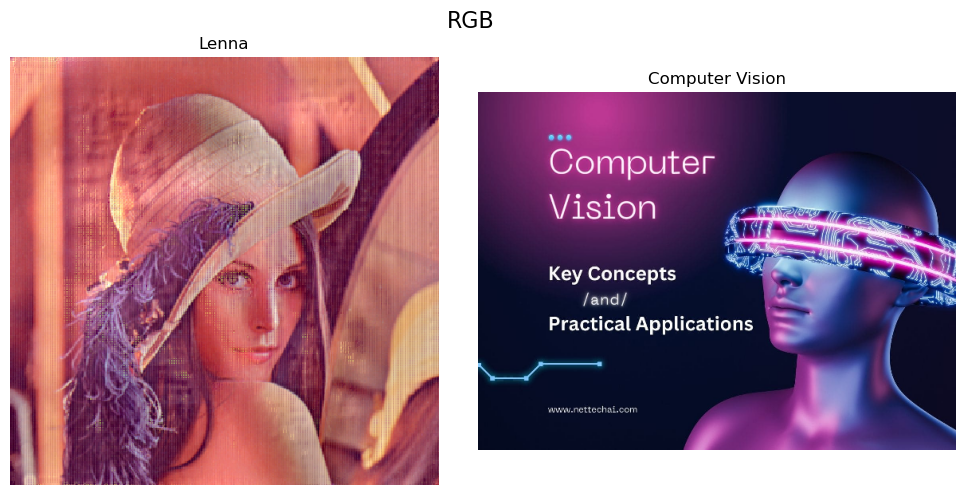

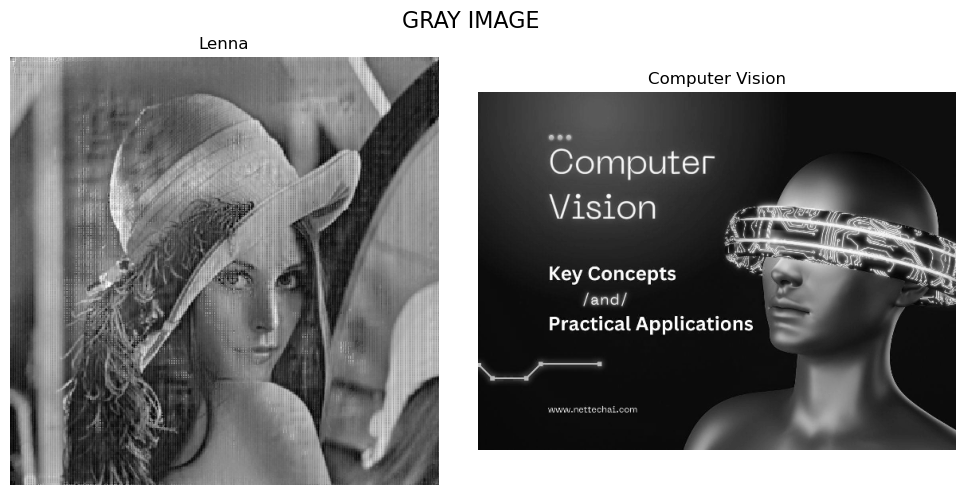

In [9]:
lenna_copy = cv2.cvtColor(re_lenna[0],cv2.COLOR_BGR2RGB)
cv_copy = cv2.cvtColor(re_cv[0],cv2.COLOR_BGR2RGB)

fig,ax = plt.subplots(1,2,figsize = (10,5))
plt.title('RGB')

ax[0].imshow(lenna_copy)
ax[0].set_title('Lenna')
ax[0].axis('off')

ax[1].imshow(cv_copy)
ax[1].set_title('Computer Vision')
ax[1].axis('off')

fig.suptitle('RGB',fontsize=16)
plt.tight_layout()
plt.show()

lenna_copy_gray = color.rgb2gray(lenna_copy)
cv_copy_gray = color.rgb2gray(cv_copy)

fig,ax = plt.subplots(1,2,figsize = (10,5))
plt.title('RGB')

ax[0].imshow(lenna_copy_gray,cmap='gray')
ax[0].set_title('Lenna')
ax[0].axis('off')

ax[1].imshow(cv_copy_gray,cmap = 'gray')
ax[1].set_title('Computer Vision')
ax[1].axis('off')

fig.suptitle('GRAY IMAGE',fontsize=16)
plt.tight_layout()
plt.show()

# USER DEFINED

In [10]:
re_lenna_bgr = re_lenna[0]
re_cv_bgr = re_cv[0]

In [11]:
def grayscale_luma(image):
    return (0.299 * image[:, :, 2] + 0.587*image[:, :, 1] + 0.11 * image[:, :, 0])  

In [12]:
def grayscale_average(image):
    return np.mean(image,axis=2)

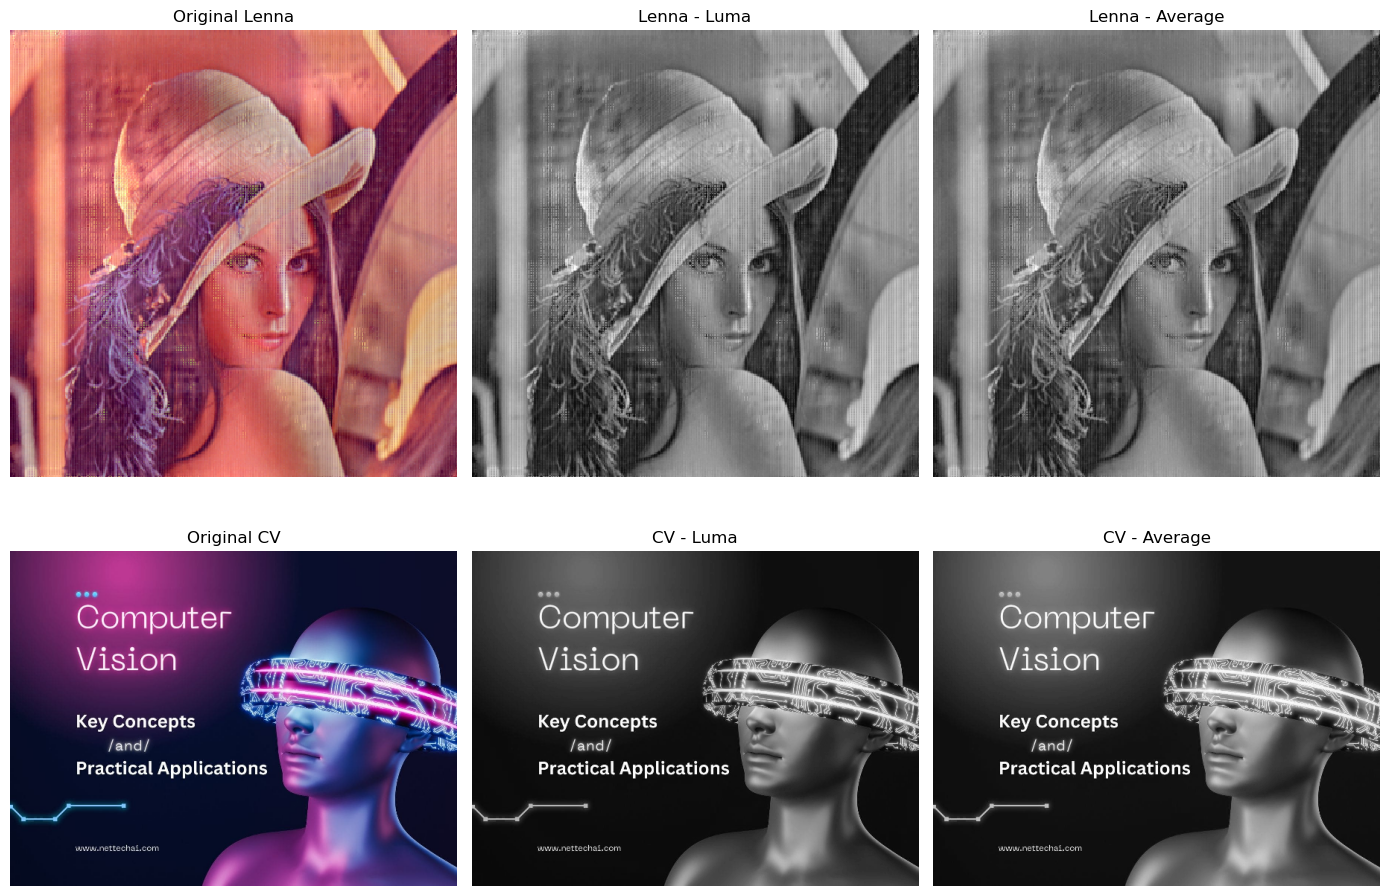

In [13]:
lenna_luma = grayscale_luma(re_lenna_bgr)
lenna_avg = grayscale_average(re_lenna_bgr)

cv_luma = grayscale_luma(re_cv_bgr)
cv_avg = grayscale_average(re_cv_bgr)


plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(re_lenna_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original Lenna")
plt.axis('off')


plt.subplot(2, 3, 2)
plt.imshow(lenna_luma, cmap='gray')
plt.title("Lenna - Luma")
plt.axis('off')


plt.subplot(2, 3, 3)
plt.imshow(lenna_avg, cmap='gray')
plt.title("Lenna - Average")
plt.axis('off')


plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(re_cv_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original CV")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(cv_luma, cmap='gray')
plt.title("CV - Luma")
plt.axis('off')


plt.subplot(2, 3, 6)
plt.imshow(cv_avg, cmap='gray')
plt.title("CV - Average")
plt.axis('off')

plt.tight_layout()
plt.show()

**Single Channel Extraction**

In [60]:
def my_plot(pos,img,name):
    plt.subplot(2, 2, pos)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{name}")
    plt.axis('off')

def extract_channel(img,i,j):
    s_img = img.copy()
    s_img[:,:,i] = 0
    s_img[:,:,j] = 0

    return s_img

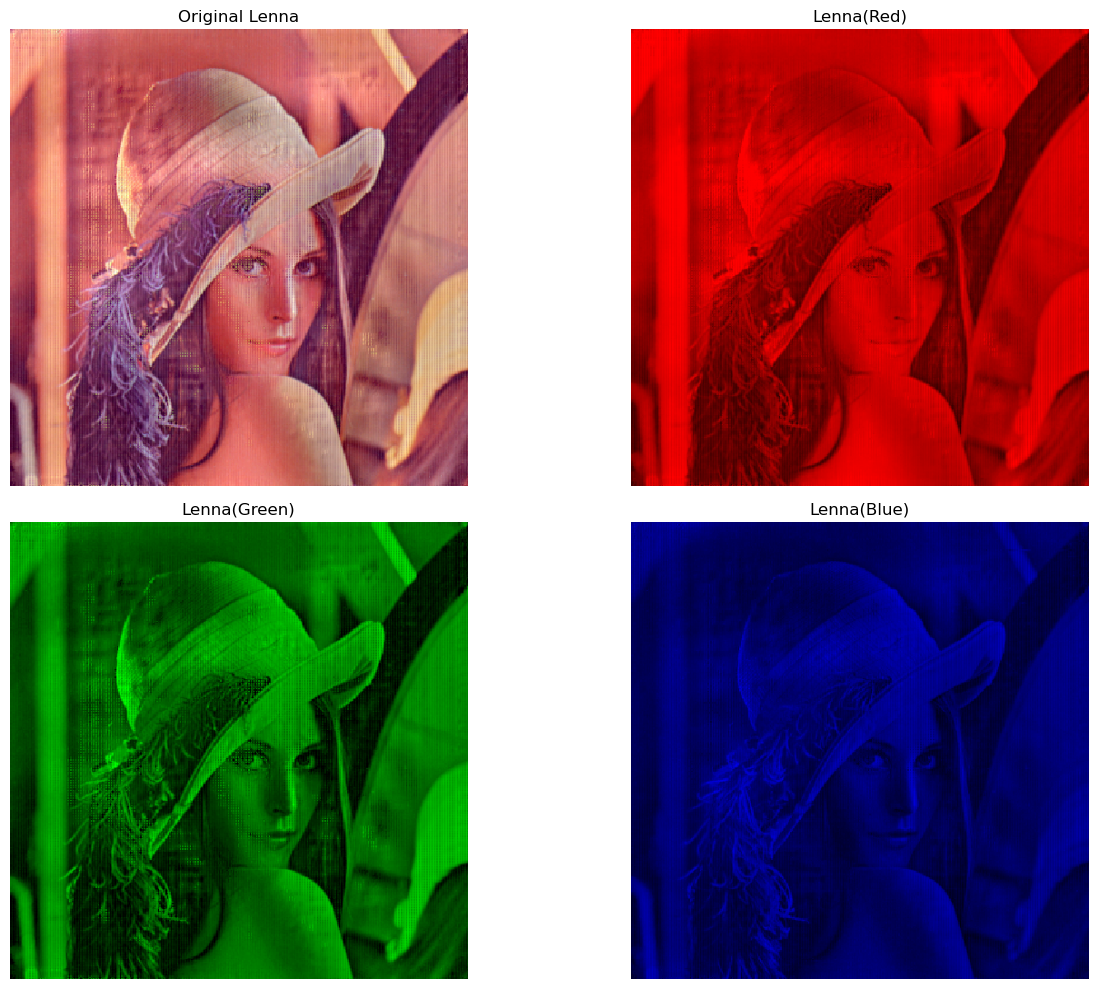

In [61]:
lenna_red = extract_channel(re_lenna[0],0,1)
lenna_green = extract_channel(re_lenna[0],0,2)                           
lenna_blue = extract_channel(re_lenna[0],1,2)

plt.figure(figsize=(14, 10))

my_plot(1,re_lenna[0],'Original Lenna')
my_plot(2,lenna_red,'Lenna(Red)')
my_plot(3,lenna_green,'Lenna(Green)')
my_plot(4,lenna_blue,'Lenna(Blue)')

plt.tight_layout()
plt.show()

# Histogram Equalization

# Using Inbuilt Function

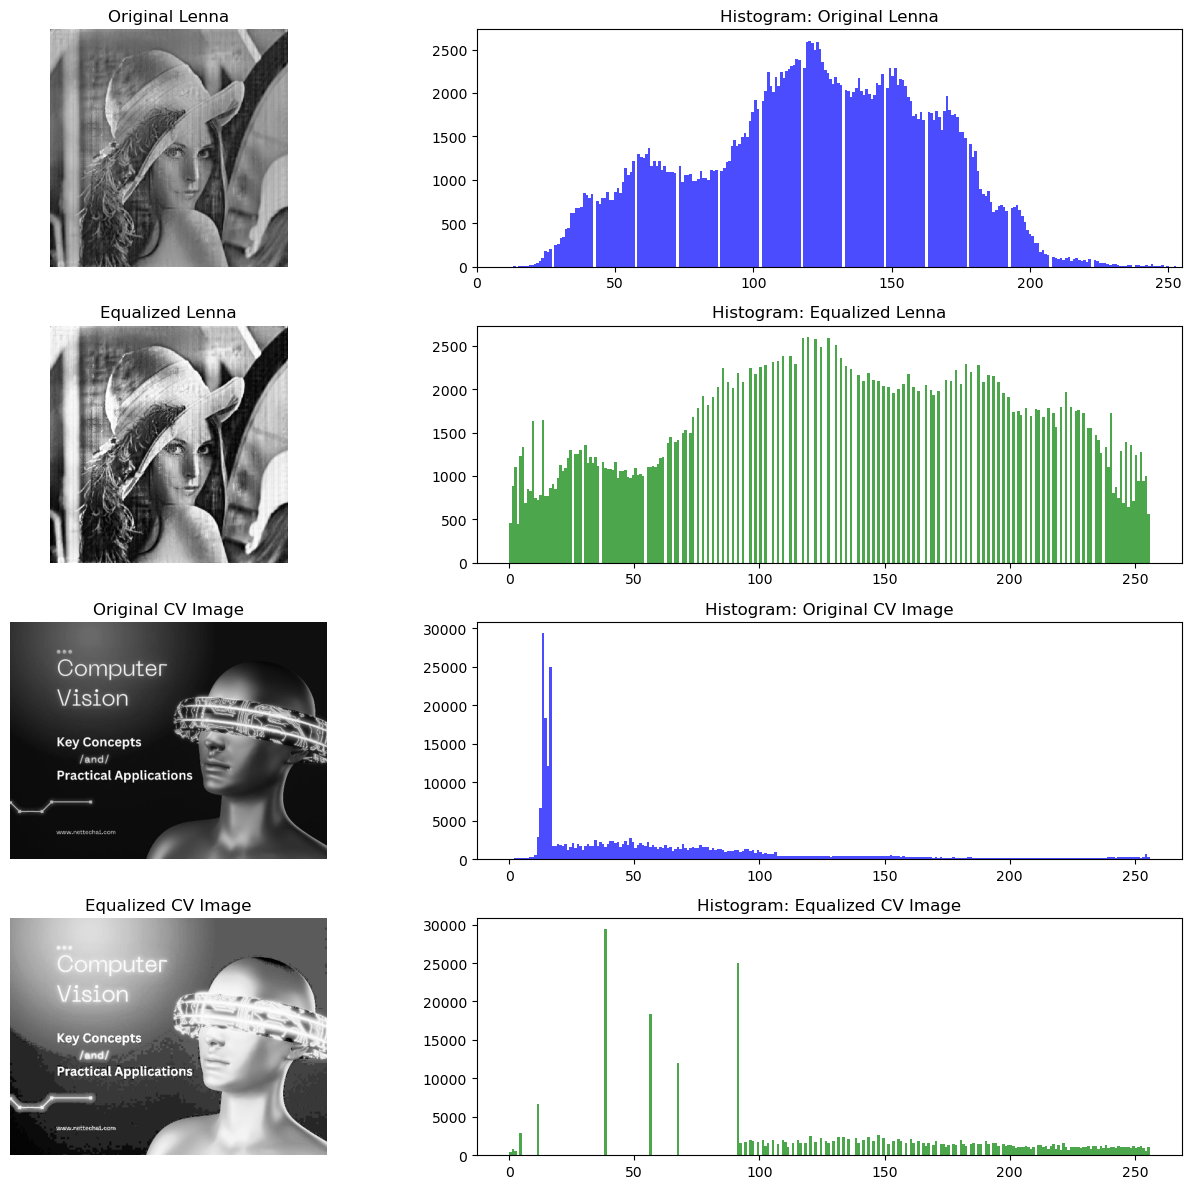

In [16]:
lenna_equalized = cv2.equalizeHist(lenna_gray)
cv_equalized = cv2.equalizeHist(cv_gray)

plt.figure(figsize=(14, 12))

plt.subplot(4, 2, 1)
plt.imshow(lenna_gray, cmap='gray')
plt.title('Original Lenna')
plt.axis('off')


plt.subplot(4, 2, 2)
plt.hist(lenna_gray.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Histogram: Original Lenna')
plt.xlim(0,255)

plt.subplot(4, 2, 3)
plt.imshow(lenna_equalized, cmap='gray')
plt.title('Equalized Lenna')
plt.axis('off')

plt.subplot(4, 2, 4)
plt.hist(lenna_equalized.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
plt.title('Histogram: Equalized Lenna')

plt.subplot(4, 2, 5)
plt.imshow(cv_gray, cmap='gray')
plt.title('Original CV Image')
plt.axis('off')

plt.subplot(4, 2, 6)
plt.hist(cv_gray.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
plt.title('Histogram: Original CV Image')

plt.subplot(4, 2, 7)
plt.imshow(cv_equalized, cmap='gray')
plt.title('Equalized CV Image')
plt.axis('off')

plt.subplot(4, 2, 8)
plt.hist(cv_equalized.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
plt.title('Histogram: Equalized CV Image')

plt.tight_layout()
plt.show()


# Manual

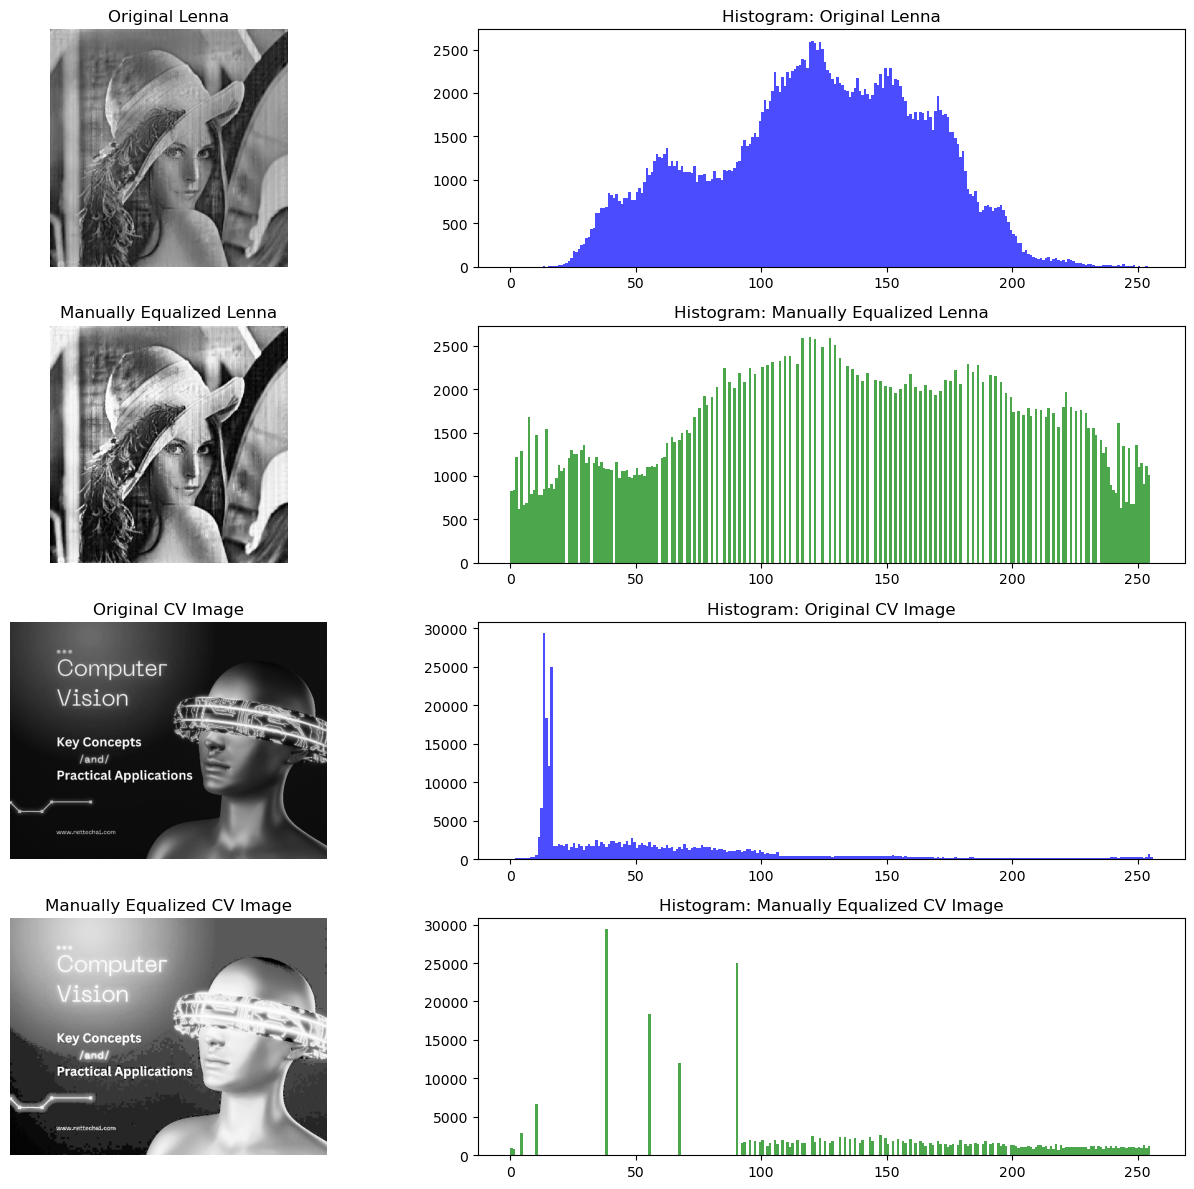

In [67]:
def manual_histogram_equalization(image):

    hist, bins = np.histogram(image.flatten(), bins=256, range=[0, 256])
    pdf = hist / np.sum(hist)
    cdf = np.cumsum(pdf)
    cdf_normalized = (cdf * 255).astype(np.uint8)
    
    equalized_image = cdf_normalized[image]
    
    return equalized_image

lenna_manual_equalized = manual_histogram_equalization(lenna_gray)
cv_manual_equalized = manual_histogram_equalization(cv_gray)

plt.figure(figsize=(14, 12))

plt.subplot(4, 2, 1)
plt.imshow(lenna_gray, cmap='gray')
plt.title('Original Lenna')
plt.axis('off')

plt.subplot(4, 2, 2)
plt.hist(lenna_gray.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
plt.title('Histogram: Original Lenna')

plt.subplot(4, 2, 3)
plt.imshow(lenna_manual_equalized, cmap='gray')
plt.title('Manually Equalized Lenna')
plt.axis('off')

plt.subplot(4, 2, 4)
plt.hist(lenna_manual_equalized.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
plt.title('Histogram: Manually Equalized Lenna')

plt.subplot(4, 2, 5)
plt.imshow(cv_gray, cmap='gray')
plt.title('Original CV Image')
plt.axis('off')

plt.subplot(4, 2, 6)
plt.hist(cv_gray.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
plt.title('Histogram: Original CV Image')

plt.subplot(4, 2, 7)
plt.imshow(cv_manual_equalized, cmap='gray')
plt.title('Manually Equalized CV Image')
plt.axis('off')

plt.subplot(4, 2, 8)
plt.hist(cv_manual_equalized.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
plt.title('Histogram: Manually Equalized CV Image')

plt.tight_layout()
plt.show()
